# Análisis estadístico — Radiación UV-C en carne de cuy

## Resuelto por: *Rudy Franklin Condori Quilla*

**Reanálisis del experimento de inactivación de *E. coli* y *S. typhimurium* mediante radiación UV-C.**

Curso: *Métodos Estadísticos para Investigaciones Experimentales* — Escuela de Posgrado, UNT.

Este notebook reproduce todos los modelos del informe:
preexperimental, DCA, DBCA, discusión del cuadrado latino, factorial 3×3 por microorganismo
y factorial 2×3×3, junto con la validación de supuestos (Shapiro–Wilk, Levene), las
comparaciones múltiples de Tukey y todos los gráficos.

Cada sección sigue el mismo esquema de trabajo: **(1)** preparar o resumir los datos,
**(2)** ejecutar el modelo o gráfico correspondiente y **(3)** interpretar el resultado.
Las figuras se guardan en disco y además se muestran dentro del notebook para facilitar su
revisión.

> Diseño recomendado: **DCA con arreglo factorial 2×3×3**. Variable respuesta: recuento de
> sobrevivientes en placa (UFC). Factores: microorganismo (2), tiempo (1, 3, 5 min) y altura
> (5, 10, 20 cm), con 4 repeticiones.

## 1. Configuración del entorno

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.graphics.factorplots import interaction_plot
import os, warnings
from IPython import get_ipython
from IPython.display import display, Image
from statsmodels.stats.multicomp import pairwise_tukeyhsd

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
FIG = "figuras"
os.makedirs(FIG, exist_ok=True)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic("matplotlib", "inline")
    except Exception:
        pass

def guardar_y_mostrar(fig, nombre):
    ruta = os.path.join(FIG, nombre)
    fig.savefig(ruta, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=ruta))
    return ruta

print("Entorno listo. Figuras ->", os.path.abspath(FIG))

Entorno listo. Figuras -> D:\Desarrollo\Maestria\examen\codigo\figuras


## 2. Carga y ordenamiento de los datos (formato *tidy*)

**Paso 1.** Incrustar los recuentos en el notebook para que sea **autocontenido y reproducible**.

**Paso 2.** Organizar cada combinación tiempo×altura con 4 réplicas (M1–M4) en una tabla ordenada.

**Paso 3.** Guardar los controles `T(0)–H(0)` para el modelo preexperimental y para calcular la
reducción respecto a `N0`.

In [106]:
# Recuentos de sobrevivientes en placa (UFC). Orden de réplicas: M1, M2, M3, M4
tratados = {
 "E. coli": {
   (1,5):[10,8,9,11],  (1,10):[12,13,12,11], (1,20):[14,17,14,15],
   (3,5):[12,13,11,11], (3,10):[6,8,7,6],     (3,20):[14,12,13,15],
   (5,5):[17,18,16,15], (5,10):[15,12,13,14], (5,20):[11,13,12,14]},
 "S. typhimurium": {
   (1,5):[13,10,12,11], (1,10):[16,17,15,17], (1,20):[17,19,20,18],
   (3,5):[10,11,10,14], (3,10):[6,5,7,6],     (3,20):[15,15,16,13],
   (5,5):[17,17,19,15], (5,10):[11,15,12,14], (5,20):[11,13,10,14]},
}
control = {"E. coli":[225,240,245,230], "S. typhimurium":[247,245,236,233]}

filas = []
for org, d in tratados.items():
    for (t,h), vals in d.items():
        for rep, v in enumerate(vals, 1):
            filas.append(dict(microorganismo=org, tiempo=t, altura=h, rep=rep, recuento=v))
df = pd.DataFrame(filas)
df["trat"] = "T"+df.tiempo.astype(str)+"_H"+df.altura.astype(str)
df.to_csv("datos_uvc.csv", index=False)
print("Observaciones tratadas:", len(df), "| controles:", sum(len(v) for v in control.values()))
df.head(10)

Observaciones tratadas: 72 | controles: 8


,microorganismo,tiempo,altura,rep,recuento,trat
0,E. coli,1,5,1,10,T1_H5
1,E. coli,1,5,2,8,T1_H5
2,E. coli,1,5,3,9,T1_H5
3,E. coli,1,5,4,11,T1_H5
4,E. coli,1,10,1,12,T1_H10
5,E. coli,1,10,2,13,T1_H10
6,E. coli,1,10,3,12,T1_H10
7,E. coli,1,10,4,11,T1_H10
8,E. coli,1,20,1,14,T1_H20
9,E. coli,1,20,2,17,T1_H20


## 3. Estadística descriptiva

**Paso 1.** Calcular `N0` como la media de los controles por microorganismo.

**Paso 2.** Resumir cada tratamiento con media, desviación estándar y número de réplicas.

**Paso 3.** Estimar la reducción logarítmica `R = log10(N0) − log10(N)` y el porcentaje de
inactivación para interpretar la magnitud del efecto.

In [107]:
N0 = {org: np.mean(v) for org, v in control.items()}
print("Carga media del control (N0):", {k: round(v,2) for k,v in N0.items()})

resumen = (df.groupby(["microorganismo","tiempo","altura"])["recuento"]
             .agg(media="mean", sd="std", n="count").reset_index())
resumen["reduccion_log10"] = resumen.apply(
    lambda r: np.log10(N0[r.microorganismo]) - np.log10(r.media), axis=1)
resumen["pct_inactivacion"] = resumen.apply(
    lambda r: 100*(1 - r.media/N0[r.microorganismo]), axis=1)
resumen.round(3)

Carga media del control (N0): {'E. coli': np.float64(235.0), 'S. typhimurium': np.float64(240.25)}


,microorganismo,tiempo,altura,media,sd,n,reduccion_log10,pct_inactivacion
0,E. coli,1,5,9.5000,1.2910,4,1.3930,95.9570
1,E. coli,1,10,12.0000,0.8160,4,1.2920,94.8940
2,E. coli,1,20,15.0000,1.4140,4,1.1950,93.6170
3,E. coli,3,5,11.7500,0.9570,4,1.3010,95.0000
4,E. coli,3,10,6.7500,0.9570,4,1.5420,97.1280
5,E. coli,3,20,13.5000,1.2910,4,1.2410,94.2550
6,E. coli,5,5,16.5000,1.2910,4,1.1540,92.9790
7,E. coli,5,10,13.5000,1.2910,4,1.2410,94.2550
8,E. coli,5,20,12.5000,1.2910,4,1.2740,94.6810
9,S. typhimurium,1,5,11.5000,1.2910,4,1.3200,95.2130


In [108]:
# Tabla de medias en formato cruzado (tiempo x altura) por microorganismo
for org in df.microorganismo.unique():
    piv = (df[df.microorganismo==org]
           .pivot_table(index="tiempo", columns="altura", values="recuento", aggfunc="mean"))
    print(f"\nMedias de recuento — {org}")
    print(piv.round(2))
    mejor = resumen[resumen.microorganismo==org].sort_values("media").iloc[0]
    print(f"  -> menor recuento: {mejor.media:.2f} en tiempo={int(mejor.tiempo)} min, altura={int(mejor.altura)} cm")


Medias de recuento — E. coli
altura      5       10      20
tiempo                        
1       9.5000 12.0000 15.0000
3      11.7500  6.7500 13.5000
5      16.5000 13.5000 12.5000
  -> menor recuento: 6.75 en tiempo=3 min, altura=10 cm

Medias de recuento — S. typhimurium
altura      5       10      20
tiempo                        
1      11.5000 16.2500 18.5000
3      11.2500  6.0000 14.7500
5      17.0000 13.0000 12.0000
  -> menor recuento: 6.00 en tiempo=3 min, altura=10 cm


## 4. Exploración gráfica

**Paso 1.** Explorar la distribución de recuentos por tiempo y por altura.

**Paso 2.** Comparar visualmente ambas especies para anticipar diferencias entre factores.

### 4.1. Distribución de recuentos por factor

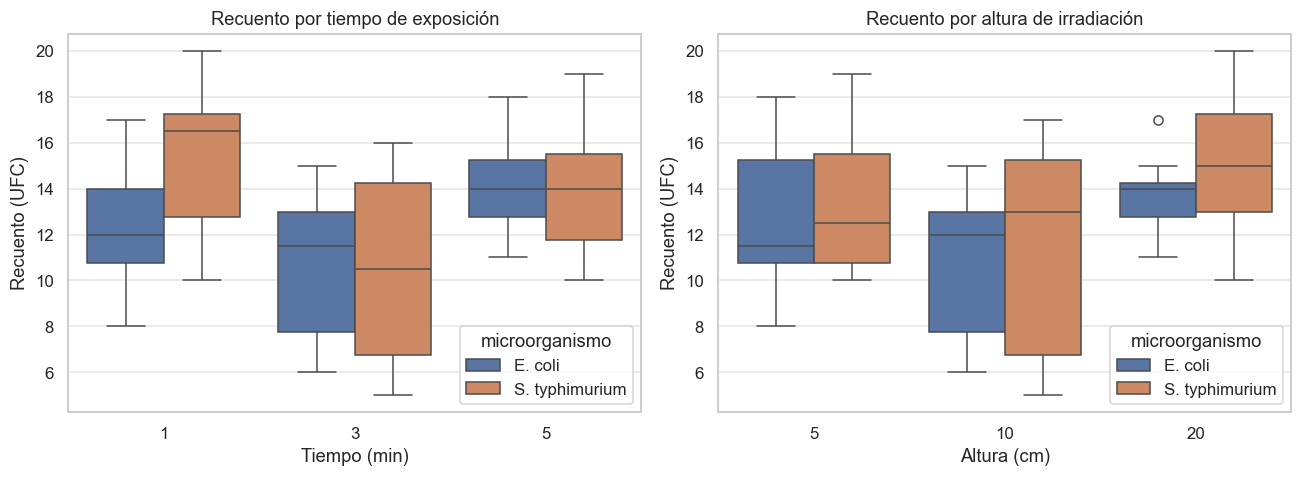

'figuras\\01_boxplots_factores.png'

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
sns.boxplot(data=df, x="tiempo", y="recuento", hue="microorganismo", ax=axes[0])
axes[0].set(title="Recuento por tiempo de exposición", xlabel="Tiempo (min)", ylabel="Recuento (UFC)")
sns.boxplot(data=df, x="altura", y="recuento", hue="microorganismo", ax=axes[1])
axes[1].set(title="Recuento por altura de irradiación", xlabel="Altura (cm)", ylabel="Recuento (UFC)")
plt.tight_layout(); guardar_y_mostrar(fig, "01_boxplots_factores.png")

### 4.2. Mapas de calor de medias (tiempo × altura)

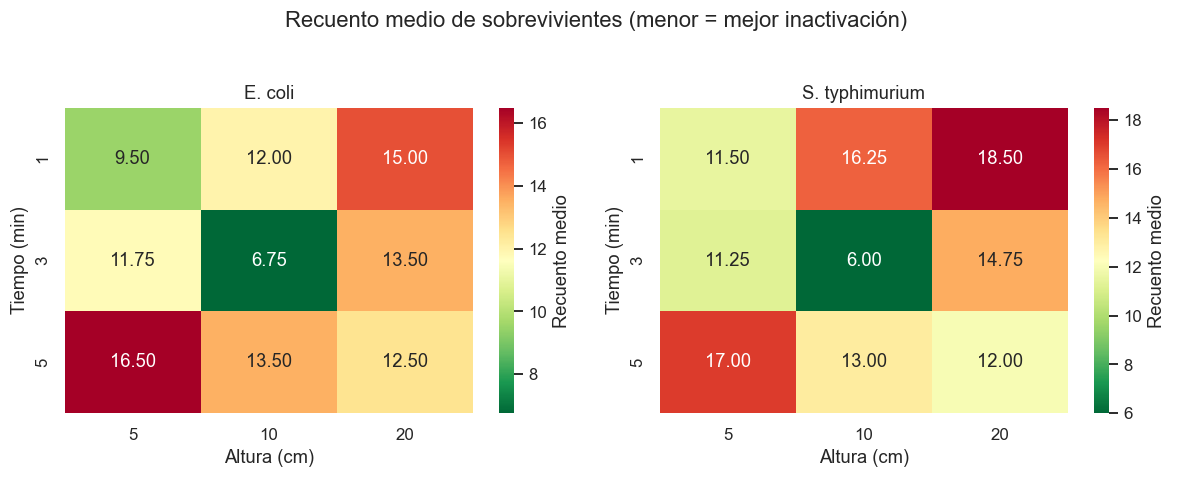

'figuras\\02_heatmaps_medias.png'

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.2))
for ax, org in zip(axes, df.microorganismo.unique()):
    piv = df[df.microorganismo==org].pivot_table(index="tiempo", columns="altura",
                                                  values="recuento", aggfunc="mean")
    sns.heatmap(piv, annot=True, fmt=".2f", cmap="RdYlGn_r", ax=ax, cbar_kws={"label":"Recuento medio"})
    ax.set(title=f"{org}", xlabel="Altura (cm)", ylabel="Tiempo (min)")
plt.suptitle("Recuento medio de sobrevivientes (menor = mejor inactivación)", y=1.03)
plt.tight_layout(); guardar_y_mostrar(fig, "02_heatmaps_medias.png")

### 4.3. % de inactivación por tratamiento

**Paso 3.** Resumir el porcentaje de inactivación por combinación tiempo×altura y validar que todas
las condiciones superan el 94 %.

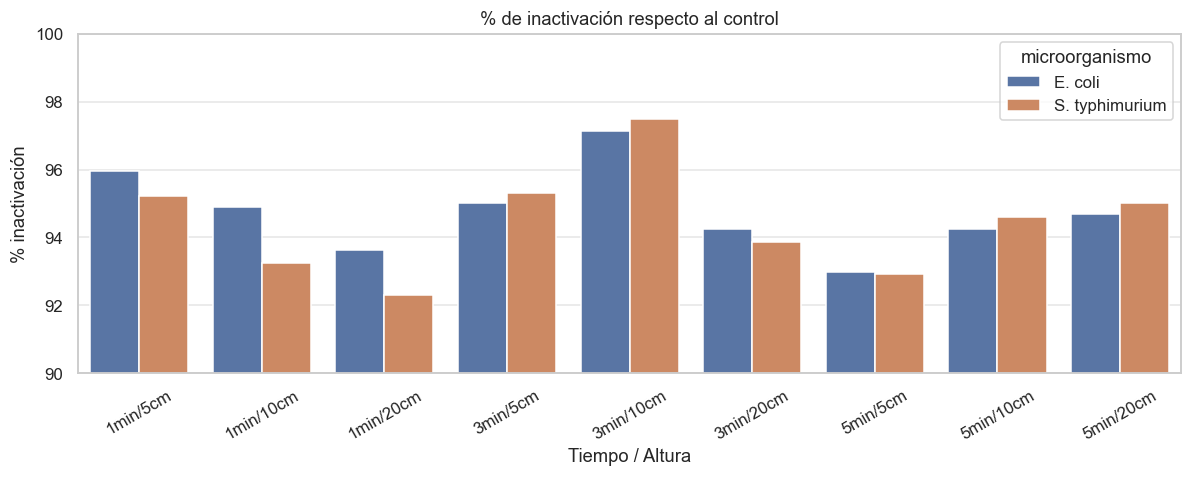

'figuras\\03_pct_inactivacion.png'

In [111]:
orden = resumen.assign(lbl=resumen.tiempo.astype(str)+"min/"+resumen.altura.astype(str)+"cm")
fig, ax = plt.subplots(figsize=(11,4.5))
sns.barplot(data=orden, x="lbl", y="pct_inactivacion", hue="microorganismo", ax=ax)
ax.set(title="% de inactivación respecto al control", xlabel="Tiempo / Altura", ylabel="% inactivación")
ax.set_ylim(90, 100); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); guardar_y_mostrar(fig, "03_pct_inactivacion.png")

## 5. Modelo 1 — Diseño preexperimental

**Paso 1.** Comparar la condición **control** (sin tratar) contra la condición **tratada**
(UV-C aplicado), es decir el esquema antes–después \(O_1\; X\; O_2\).

**Paso 2.** Formular la hipótesis nula y alternativa para ambos microorganismos.

**Paso 3.** Aplicar la prueba *t* de Welch para verificar si la radiación UV-C reduce la carga
microbiana.

$$Y_{ij} = \mu + \tau_i + e_{ij}$$

**Hipótesis:** \(H_0:\ \mu_{control} = \mu_{tratado}\) vs \(H_1:\ \mu_{control} \neq \mu_{tratado}\).

Es un *t* de dos muestras (control vs. tratado) por microorganismo. Sólo responde *si hubo
reducción*, no *cuál tiempo/altura es óptimo*.

In [112]:
print("MODELO PREEXPERIMENTAL (control vs tratado)\n" + "="*48)
for org in df.microorganismo.unique():
    c = np.array(control[org], dtype=float)
    t = df[df.microorganismo==org]["recuento"].values.astype(float)
    tstat, p = stats.ttest_ind(c, t, equal_var=False)
    print(f"\n{org}:")
    print(f"  media control = {c.mean():.2f} | media tratado = {t.mean():.2f}")
    print(f"  reducción     = {100*(1-t.mean()/c.mean()):.2f}%")
    print(f"  t = {tstat:.3f}, p = {p:.3e}  -> {'RECHAZA H0 (hay efecto)' if p<0.05 else 'no rechaza H0'}")

MODELO PREEXPERIMENTAL (control vs tratado)

E. coli:
  media control = 235.00 | media tratado = 12.33
  reducción     = 94.75%
  t = 48.502, p = 1.567e-05  -> RECHAZA H0 (hay efecto)

S. typhimurium:
  media control = 240.25 | media tratado = 13.36
  reducción     = 94.44%
  t = 65.577, p = 3.880e-06  -> RECHAZA H0 (hay efecto)


## 6. Modelo 2 — Diseño Completamente al Azar (DCA)

**Paso 1.** Tratar cada combinación tiempo×altura como **un** tratamiento independiente
(9 tratamientos).

**Paso 2.** Ajustar un ANOVA de un factor por microorganismo.

**Paso 3.** Interpretar si existen diferencias significativas entre tratamientos, aunque sin
separar todavía tiempo, altura e interacción.

$$Y_{ij} = \mu + \tau_i + e_{ij}, \qquad H_0:\ \mu_1=\cdots=\mu_9$$

Se ajusta por microorganismo.

In [113]:
def anova_dca(sub, org):
    modelo = ols("recuento ~ C(trat)", data=sub).fit()
    tabla = anova_lm(modelo, typ=2)
    print(f"\nANOVA DCA — {org}")
    print(tabla.round(4))
    return modelo

mod_dca = {}
for org in df.microorganismo.unique():
    mod_dca[org] = anova_dca(df[df.microorganismo==org], org)


ANOVA DCA — E. coli
           sum_sq      df       F  PR(>F)
C(trat)  267.5000  8.0000 23.4497  0.0000
Residual  38.5000 27.0000     NaN     NaN

ANOVA DCA — S. typhimurium
           sum_sq      df       F  PR(>F)
C(trat)  456.0556  8.0000 26.4238  0.0000
Residual  58.2500 27.0000     NaN     NaN


## 7. Modelo 3 — Diseño de Bloques Completamente al Azar (DBCA)

**Paso 1.** Considerar la repetición (M1–M4) como **bloque** y verificar si aporta variación
sistemática.

**Paso 2.** Ajustar el modelo con tratamientos + bloques.

**Paso 3.** Evaluar el p-valor del bloque para decidir si el bloqueo es útil.

$$Y_{ij} = \mu + \tau_i + \beta_j + e_{ij}$$

Permite verificar si el bloqueo (réplica) aporta. Se espera que **no** sea significativo,
porque las réplicas no representan una fuente sistemática real de variación.

In [114]:
def anova_dbca(sub, org):
    modelo = ols("recuento ~ C(trat) + C(rep)", data=sub).fit()
    tabla = anova_lm(modelo, typ=2)
    print(f"\nANOVA DBCA — {org}  (tratamientos + bloque=réplica)")
    print(tabla.round(4))
    p_bloque = tabla.loc["C(rep)","PR(>F)"]
    print(f"  Bloques: p = {p_bloque:.3f} -> {'significativo' if p_bloque<0.05 else 'NO significativo (bloqueo no aporta)'}")
    return modelo

mod_dbca = {}
for org in df.microorganismo.unique():
    mod_dbca[org] = anova_dbca(df[df.microorganismo==org], org)


ANOVA DBCA — E. coli  (tratamientos + bloque=réplica)
           sum_sq      df       F  PR(>F)
C(trat)  267.5000  8.0000 22.5351  0.0000
C(rep)     2.8889  3.0000  0.6490  0.5913
Residual  35.6111 24.0000     NaN     NaN
  Bloques: p = 0.591 -> NO significativo (bloqueo no aporta)

ANOVA DBCA — S. typhimurium  (tratamientos + bloque=réplica)
           sum_sq      df       F  PR(>F)
C(trat)  456.0556  8.0000 24.6517  0.0000
C(rep)     2.7500  3.0000  0.3964  0.7568
Residual  55.5000 24.0000     NaN     NaN
  Bloques: p = 0.757 -> NO significativo (bloqueo no aporta)


## 8. Modelo 4 — Cuadrado Latino (¿aplica?)

**Paso 1.** Revisar si el cuadrado latino es compatible con la estructura del experimento.

**Paso 2.** Verificar si tiempo y altura actúan como bloques o como factores de interés.

**Paso 3.** Comparar el modelo aditivo con el modelo que incluye interacción para mostrar por
qué el cuadrado latino **no corresponde** a este caso.

El cuadrado latino exige **dos** factores de bloqueo cruzados y un número igual de
tratamientos, filas y columnas. **No corresponde** a este experimento porque:

- Tiempo y altura **no** son bloques: son **factores experimentales de interés**.
- Su **interacción** tiempo×altura es justamente lo que se quiere estimar, y el cuadrado
  latino la confunde con el error.
- No hay dos fuentes de ruido cruzadas que controlar.

A continuación se demuestra **numéricamente** por qué descartarlo: si se forzara un modelo
puramente aditivo (sin interacción), la interacción quedaría escondida en el error.

In [115]:
org = "E. coli"
sub = df[df.microorganismo==org]
aditivo = ols("recuento ~ C(tiempo) + C(altura)", data=sub).fit()
completo = ols("recuento ~ C(tiempo) * C(altura)", data=sub).fit()
print(f"{org}: modelo ADITIVO (estilo cuadrado latino, sin interacción)")
print(f"  SC error aditivo  = {aditivo.ssr:.2f}  (gl={int(aditivo.df_resid)})")
print(f"  SC error completo = {completo.ssr:.2f}  (gl={int(completo.df_resid)})")
print(f"  -> La interacción tiempo×altura aporta SC = {aditivo.ssr-completo.ssr:.2f},")
print("     que un diseño tipo cuadrado latino enviaría erróneamente al error.")

E. coli: modelo ADITIVO (estilo cuadrado latino, sin interacción)
  SC error aditivo  = 179.83  (gl=31)
  SC error completo = 38.50  (gl=27)
  -> La interacción tiempo×altura aporta SC = 141.33,
     que un diseño tipo cuadrado latino enviaría erróneamente al error.


## 9. Modelo 5 — Factorial 3×3 por microorganismo

**Paso 1.** Separar tiempo y altura como factores experimentales de interés.

**Paso 2.** Ajustar el factorial 3×3 por microorganismo para descomponer el efecto total.

**Paso 3.** Interpretar los efectos principales y la interacción tiempo×altura.

$$Y_{ijk} = \mu + \alpha_i + \beta_j + (\alpha\beta)_{ij} + e_{ijk}$$

con \(\alpha\) = tiempo, \(\beta\) = altura. Descompone los 9 tratamientos del DCA en
**efectos principales** (tiempo, altura) e **interacción**.

In [116]:
mod_fac = {}
for org in df.microorganismo.unique():
    sub = df[df.microorganismo==org]
    modelo = ols("recuento ~ C(tiempo) * C(altura)", data=sub).fit()
    tabla = anova_lm(modelo, typ=2)
    mod_fac[org] = modelo
    print(f"\nANOVA Factorial 3x3 — {org}")
    print(tabla.round(4))
    print(f"  R^2 = {modelo.rsquared:.3f}")


ANOVA Factorial 3x3 — E. coli
                      sum_sq      df       F  PR(>F)
C(tiempo)            74.0000  2.0000 25.9481  0.0000
C(altura)            52.1667  2.0000 18.2922  0.0000
C(tiempo):C(altura) 141.3333  4.0000 24.7792  0.0000
Residual             38.5000 27.0000     NaN     NaN
  R^2 = 0.874

ANOVA Factorial 3x3 — S. typhimurium
                      sum_sq      df       F  PR(>F)
C(tiempo)           142.7222  2.0000 33.0773  0.0000
C(altura)            66.8889  2.0000 15.5021  0.0000
C(tiempo):C(altura) 246.4444  4.0000 28.5579  0.0000
Residual             58.2500 27.0000     NaN     NaN
  R^2 = 0.887


### 9.1. Gráficos de interacción tiempo × altura

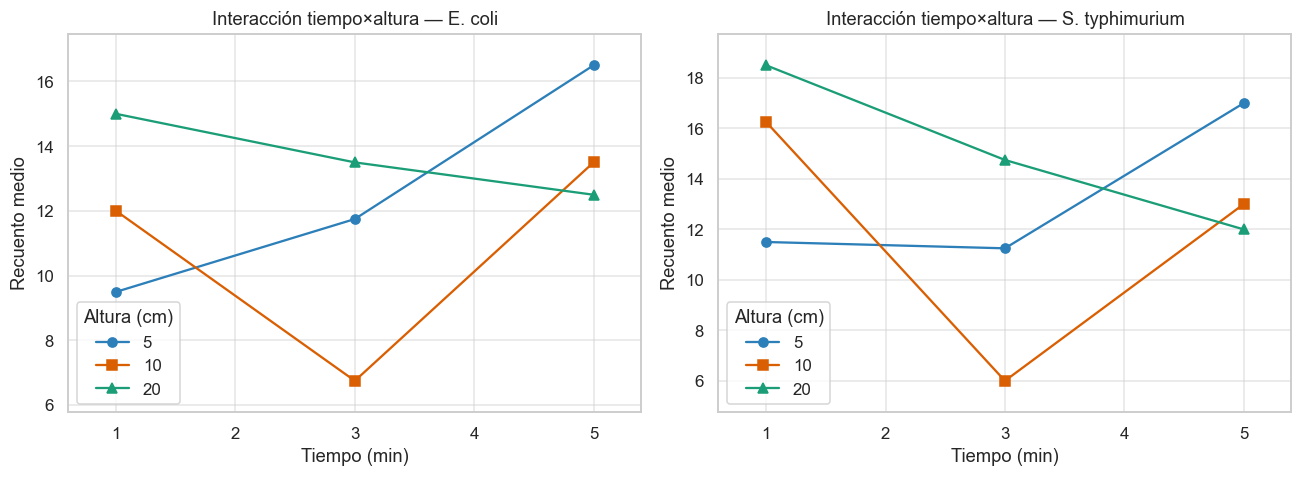

'figuras\\04_interaccion_tiempo_altura.png'

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
for ax, org in zip(axes, df.microorganismo.unique()):
    sub = df[df.microorganismo==org]
    interaction_plot(x=sub.tiempo.values, trace=sub.altura.values, response=sub.recuento.values,
                     ax=ax, markers=["o","s","^"], colors=["#2c7fb8","#d95f02","#1b9e77"])
    ax.set(title=f"Interacción tiempo×altura — {org}", xlabel="Tiempo (min)", ylabel="Recuento medio")
    ax.legend(title="Altura (cm)")
plt.tight_layout(); guardar_y_mostrar(fig, "04_interaccion_tiempo_altura.png")

## 10. Modelo 6 — Factorial 2×3×3 (modelo recomendado)

**Paso 1.** Integrar microorganismo, tiempo y altura en un único modelo factorial.

**Paso 2.** Evaluar todas las interacciones posibles para no perder información.

**Paso 3.** Usar este modelo como referencia principal porque representa la estructura real del
experimento.

$$Y_{ijkl} = \mu + A_i + B_j + C_k + (AB)_{ij} + (AC)_{ik} + (BC)_{jk} + (ABC)_{ijk} + e_{ijkl}$$

con \(A\) = microorganismo, \(B\) = tiempo, \(C\) = altura. Es el modelo **más completo**:
compara microorganismos y todas las interacciones en un solo análisis.

In [118]:
modelo_full = ols("recuento ~ C(microorganismo) * C(tiempo) * C(altura)", data=df).fit()
tabla_full = anova_lm(modelo_full, typ=2)
print("ANOVA Factorial 2x3x3 (modelo completo)")
print(tabla_full.round(4))
print(f"\nR^2 = {modelo_full.rsquared:.3f} | R^2 ajustado = {modelo_full.rsquared_adj:.3f}")
tabla_full

ANOVA Factorial 2x3x3 (modelo completo)
                                        sum_sq      df       F  PR(>F)
C(microorganismo)                      19.0139  1.0000 10.6124  0.0019
C(tiempo)                             172.1944  2.0000 48.0543  0.0000
C(altura)                             117.3611  2.0000 32.7519  0.0000
C(microorganismo):C(tiempo)            44.5278  2.0000 12.4264  0.0000
C(microorganismo):C(altura)             1.6944  2.0000  0.4729  0.6258
C(tiempo):C(altura)                   378.1389  4.0000 52.7636  0.0000
C(microorganismo):C(tiempo):C(altura)   9.6389  4.0000  1.3450  0.2653
Residual                               96.7500 54.0000     NaN     NaN

R^2 = 0.885 | R^2 ajustado = 0.848


,sum_sq,df,F,PR(>F)
C(microorganismo),19.0139,1.0000,10.6124,0.0019
C(tiempo),172.1944,2.0000,48.0543,0.0000
C(altura),117.3611,2.0000,32.7519,0.0000
C(microorganismo):C(tiempo),44.5278,2.0000,12.4264,0.0000
C(microorganismo):C(altura),1.6944,2.0000,0.4729,0.6258
C(tiempo):C(altura),378.1389,4.0000,52.7636,0.0000
C(microorganismo):C(tiempo):C(altura),9.6389,4.0000,1.3450,0.2653
Residual,96.7500,54.0000,NaN,NaN


## 11. Validación de supuestos del modelo 2×3×3

**Paso 1.** Extraer los residuos del modelo completo.

**Paso 2.** Evaluar normalidad con Shapiro–Wilk y homogeneidad con Levene.

**Paso 3.** Complementar con diagnóstico gráfico de residuos.

Sobre los residuos del modelo completo:
- **Normalidad:** Shapiro–Wilk (global y por microorganismo).
- **Homogeneidad de varianzas:** Levene entre los 9 tratamientos.
- **Diagnóstico gráfico:** Q–Q plot y residuos vs. ajustados.

In [119]:
res = modelo_full.resid
print("NORMALIDAD (Shapiro-Wilk)")
W, p = stats.shapiro(res)
print(f"  Global: W = {W:.4f}, p = {p:.4f} -> {'normal' if p>0.05 else 'dudosa'}")
for org in df.microorganismo.unique():
    m = ols("recuento ~ C(tiempo)*C(altura)", data=df[df.microorganismo==org]).fit()
    W, p = stats.shapiro(m.resid)
    print(f"  {org}: W = {W:.4f}, p = {p:.4f} -> {'normal' if p>0.05 else 'dudosa'}")

print("\nHOMOGENEIDAD DE VARIANZAS (Levene, 9 tratamientos)")
grupos = [g["recuento"].values for _,g in df.groupby(["microorganismo","trat"])]
W, p = stats.levene(*grupos, center="median")
print(f"  Global: estadístico = {W:.4f}, p = {p:.4f} -> {'homogéneas' if p>0.05 else 'heterogéneas'}")
for org in df.microorganismo.unique():
    gs = [g["recuento"].values for _,g in df[df.microorganismo==org].groupby("trat")]
    W, p = stats.levene(*gs, center="median")
    print(f"  {org}: estadístico = {W:.4f}, p = {p:.4f} -> {'homogéneas' if p>0.05 else 'heterogéneas'}")

NORMALIDAD (Shapiro-Wilk)
  Global: W = 0.9686, p = 0.0685 -> normal
  E. coli: W = 0.9337, p = 0.0325 -> dudosa
  S. typhimurium: W = 0.9659, p = 0.3250 -> normal

HOMOGENEIDAD DE VARIANZAS (Levene, 9 tratamientos)
  Global: estadístico = 0.5472, p = 0.9146 -> homogéneas
  E. coli: estadístico = 0.3393, p = 0.9426 -> homogéneas
  S. typhimurium: estadístico = 0.6526, p = 0.7272 -> homogéneas


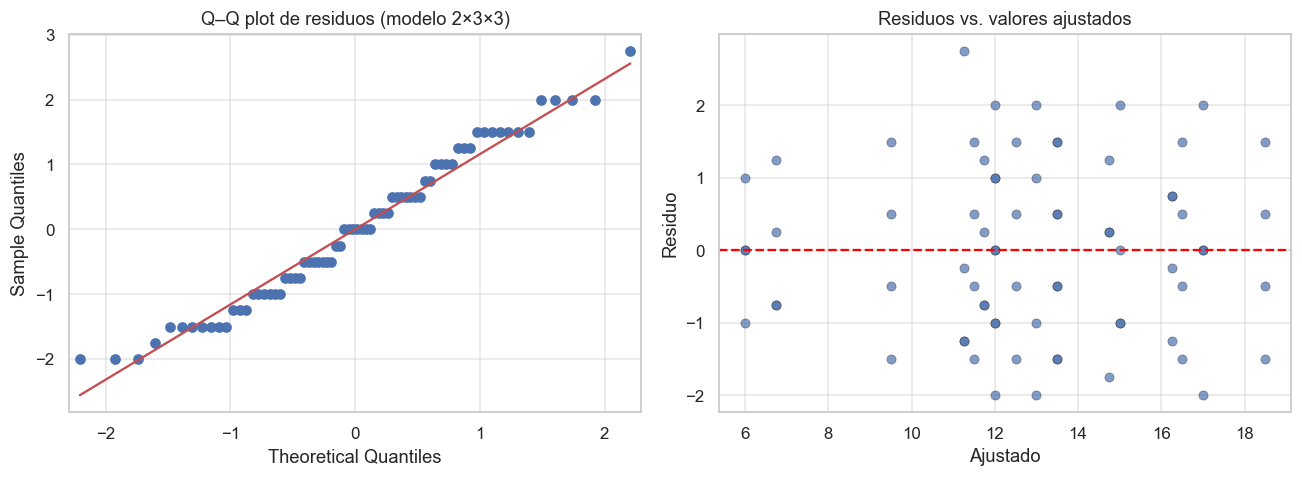

'figuras\\05_diagnostico_residuos.png'

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
sm.qqplot(res, line="s", ax=axes[0])
axes[0].set_title("Q–Q plot de residuos (modelo 2×3×3)")
axes[1].scatter(modelo_full.fittedvalues, res, alpha=0.7, edgecolor="k", linewidth=0.3)
axes[1].axhline(0, color="red", ls="--")
axes[1].set(title="Residuos vs. valores ajustados", xlabel="Ajustado", ylabel="Residuo")
plt.tight_layout(); guardar_y_mostrar(fig, "05_diagnostico_residuos.png")

## 12. Comparaciones múltiples (Tukey HSD)

**Paso 1.** Confirmar que la interacción tiempo×altura es significativa.

**Paso 2.** Aplicar Tukey sobre los 9 tratamientos por microorganismo.

**Paso 3.** Identificar el tratamiento óptimo por comparación múltiple de medias.

Como la interacción tiempo×altura es significativa, el tratamiento óptimo se identifica por
**combinación de niveles**. Se aplica Tukey sobre los 9 tratamientos por microorganismo.

In [120]:
for org in df.microorganismo.unique():
    sub = df[df.microorganismo==org]
    tuk = pairwise_tukeyhsd(sub.recuento, sub.trat, alpha=0.05)
    print(f"\nTukey HSD — {org}")
    print(tuk.summary())
    medias = sub.groupby("trat").recuento.mean().sort_values()
    print(f"  Tratamiento con menor recuento: {medias.index[0]} (media={medias.iloc[0]:.2f})")


Tukey HSD — E. coli
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
T1_H10 T1_H20      3.0 0.0326   0.1589  5.8411   True
T1_H10  T1_H5     -2.5  0.118  -5.3411  0.3411  False
T1_H10 T3_H10    -5.25    0.0  -8.0911 -2.4089   True
T1_H10 T3_H20      1.5 0.6961  -1.3411  4.3411  False
T1_H10  T3_H5    -0.25    1.0  -3.0911  2.5911  False
T1_H10 T5_H10      1.5 0.6961  -1.3411  4.3411  False
T1_H10 T5_H20      0.5 0.9995  -2.3411  3.3411  False
T1_H10  T5_H5      4.5 0.0004   1.6589  7.3411   True
T1_H20  T1_H5     -5.5    0.0  -8.3411 -2.6589   True
T1_H20 T3_H10    -8.25    0.0 -11.0911 -5.4089   True
T1_H20 T3_H20     -1.5 0.6961  -4.3411  1.3411  False
T1_H20  T3_H5    -3.25 0.0162  -6.0911 -0.4089   True
T1_H20 T5_H10     -1.5 0.6961  -4.3411  1.3411  False
T1_H20 T5_H20     -2.5  0.118  -5.3411  0.3411  False
T1_H20  T5_H5      1.5 0.6961  -1.3411  4.3411  False
 T1_H5 

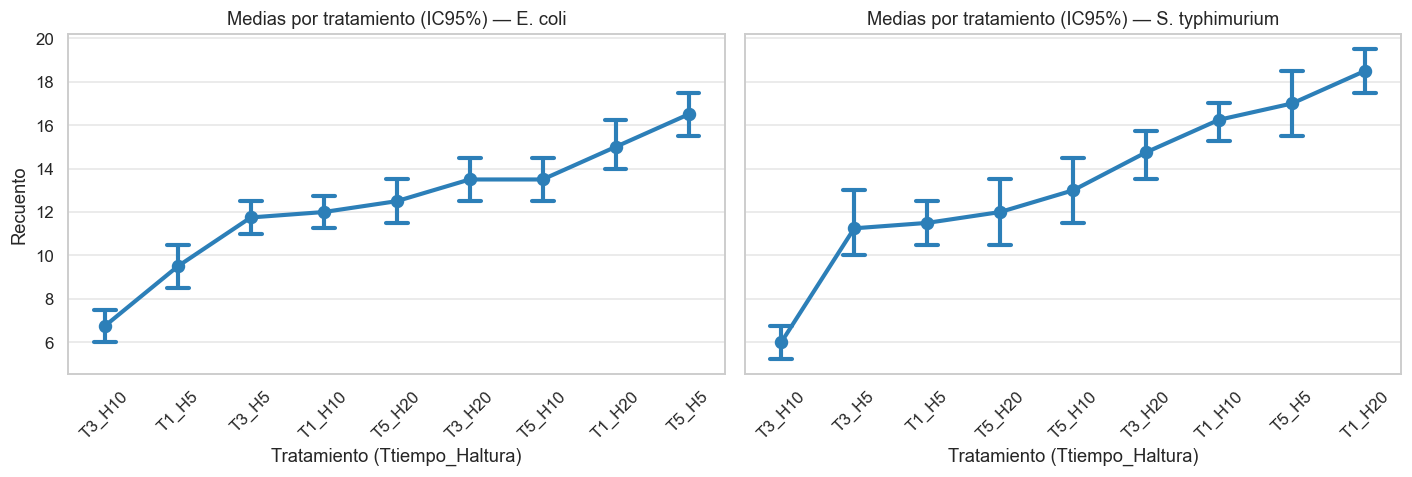

'figuras\\06_medias_tukey.png'

In [121]:
# Visualización de las medias por tratamiento con IC
fig, axes = plt.subplots(1, 2, figsize=(13,4.5), sharey=True)
for ax, org in zip(axes, df.microorganismo.unique()):
    sub = df[df.microorganismo==org]
    orden = sub.groupby("trat").recuento.mean().sort_values().index
    sns.pointplot(data=sub, x="trat", y="recuento", order=orden, ax=ax,
                  errorbar="ci", capsize=.3, color="#2c7fb8")
    ax.set(title=f"Medias por tratamiento (IC95%) — {org}", xlabel="Tratamiento (Ttiempo_Haltura)",
           ylabel="Recuento")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); guardar_y_mostrar(fig, "06_medias_tukey.png")

## 13. Comparación general de modelos

**Paso 1.** Reunir, en una sola tabla, la utilidad de cada modelo evaluado.

**Paso 2.** Comparar su aplicabilidad y su capacidad para explicar la variación observada.

**Paso 3.** Seleccionar el modelo recomendado a partir de la evidencia previa.

In [122]:
comparacion = pd.DataFrame([
 ["Preexperimental","Parcial","Detecta reducción global","Insuficiente: no evalúa tiempo/altura/interacción"],
 ["DCA","Sí","Tratamientos significativos (p<0.001)","Válido, pero no separa efectos principales"],
 ["DBCA","Condicional","Tratamientos signif.; bloques NO","No mejora al DCA; bloqueo injustificado"],
 ["Cuadrado latino","No","No corresponde a la estructura","Confundiría la interacción con el error"],
 ["Factorial 3×3","Sí","Tiempo, altura e interacción signif.","Muy adecuado por microorganismo"],
 ["Factorial 2×3×3","Sí","Evalúa microorg., tiempo, altura e interacc.","MODELO RECOMENDADO (más completo)"],
], columns=["Modelo","Aplicabilidad","Resultado principal","Evaluación"])
comparacion

,Modelo,Aplicabilidad,Resultado principal,Evaluación
0,Preexperimental,Parcial,Detecta reducción global,Insuficiente: no evalúa tiempo/altura/interacción
1,DCA,Sí,Tratamientos significativos (p<0.001),"Válido, pero no separa efectos principales"
2,DBCA,Condicional,Tratamientos signif.; bloques NO,No mejora al DCA; bloqueo injustificado
3,Cuadrado latino,No,No corresponde a la estructura,Confundiría la interacción con el error
4,Factorial 3×3,Sí,"Tiempo, altura e interacción signif.",Muy adecuado por microorganismo
5,Factorial 2×3×3,Sí,"Evalúa microorg., tiempo, altura e interacc.",MODELO RECOMENDADO (más completo)


## 14. Conclusiones del reanálisis

**Paso 1.** Integrar la evidencia obtenida en los modelos y en los gráficos.

**Paso 2.** Sintetizar qué diseño es correcto y cuál es el tratamiento óptimo.

**Paso 3.** Redactar conclusiones y recomendaciones finales de forma clara y verificable.

1. **Hay efecto UV-C:** el modelo preexperimental confirma una reducción ≈95 % respecto al
   control en ambos patógenos (*p* ≪ 0.001).
2. **El diseño correcto es factorial**, no preexperimental: el experimento cruza tiempo y
   altura con réplicas.
3. **DCA y DBCA** detectan diferencias entre tratamientos, pero el bloqueo por réplica **no
   es significativo** → el DBCA no aporta sobre el DCA.
4. **El cuadrado latino no aplica:** tiempo y altura son factores, no bloques.
5. **El factorial 2×3×3 es el modelo recomendado.** Resultan significativos microorganismo,
   tiempo, altura, la interacción microorganismo×tiempo y, sobre todo, la **interacción
   tiempo×altura** (*p* ≪ 0.001). La interacción triple no es significativa.
6. **Supuestos:** homogeneidad de varianzas se cumple holgadamente; la normalidad global es
   aceptable (en *E. coli* es dudosa → se sugiere transformación log).
7. **Tratamiento óptimo (confirmado por Tukey):** **3 min – 10 cm**, con recuentos medios de
   **6.75** (*E. coli*) y **6.00** (*S. typhimurium*) — los más bajos del experimento.
8. **Veredicto:** la conclusión experimental de la tesis es correcta, pero su **diseño y
   análisis estadístico deben reformularse** (factorial, hipótesis bien planteadas, supuestos
   validados, ANOVA completo, Tukey y, preferiblemente, escala logarítmica).